# Off-diagonal CMB covariance

The BipoSH formalism captures statistical isotropy violations via coefficients that are an equivalent representation of the spherical harmonic correlation matrix, and are given by 

$A^{LM}_{\ell\ell'} = \sum_{m m'} (-1)^{m'} \langle a_{\ell m}a_{\ell' m'}^*\rangle \mathcal{C}^{LM}_{\ell m\ell'-m'}$

where $\mathcal{C}^{LM}_{\ell m\ell'-m'}$ are Clebsch-Gordan coefficients. We use 

$\mathcal{C}^{LM}_{\ell m\ell'm'}=(-1)^{\ell-\ell'+M} \sqrt{2L+1}\begin{pmatrix}
\ell & \ell' & L\\
m & m' & -M
\end{pmatrix}$

The usual  CMB angular power spectrum corresponds to fixing $L=0$, obtaining $A^{00}_{l l^{\prime}}  = (-1)^l \sqrt{2l+1} C_{l} \delta_{l l^{\prime}}$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from classy import Class
from scipy.interpolate import CubicSpline
from scipy.special import gammaln

plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'

# Planck 2018 baseline
h_planck = 0.6688
omega_cdm = 0.1206
omega_b = 0.02212
tau_reio = 0.05522
As = 2.092e-9
ns = 0.962
T_cmb = 2.7255 * 1.e6 

## Run CLASS

We need the **transfer module** to run — that requires at least one CMB $C_\ell$ output (`tCl`, `pCl`, `lCl`).

In [2]:
k_out = [1e-4, 1e-3, 1e-2, 1e-1]  # Mpc^-1

precision_settings = {
    'start_small_k_at_tau_c_over_tau_h': 0.0004,
    'start_large_k_at_tau_h_over_tau_k': 0.001,
    'tol_perturbations_integration': 1.e-8,
    'k_per_decade_primordial': 30.0,
}

settings = {
    'h': h_planck, 'omega_b': omega_b, 'omega_cdm': omega_cdm,
    'A_s': As, 'n_s': ns, 'tau_reio': tau_reio,
    'output': 'tCl,pCl,lCl', 'lensing': 'yes',
    'l_max_scalars': 2500,
    'k_output_values': str(k_out).strip('[]'),
}
settings.update(precision_settings)

lcdm = Class()
lcdm.set(settings)
lcdm.compute()

frac = 1.#-1.e-6
common_settings  = {
            'h' : h_planck, 
            'omega_b' : omega_b,
            'Omega_cdm' : omega_cdm*(1-frac)/h_planck**2,
            'N_ncdm' : 0.,
            'Omega_fld' : 0.,
            'Omega_vf' : frac*omega_cdm/h_planck**2,
            'attractor_ic_vf' : 'yes',
            'vector_background_mode': 'bianchi',
            'YHe' : 'BBN',
            'tau_reio':tau_reio,
            'ic' : 'ad',
            'gauge' : 'synchronous',
            'A_s' : As,
            'n_s' : ns,
            'l_max_scalars': 2500, 'k_output_values': str(k_out).strip('[]'),
            'modes' : 's',
            'recombination' : 'RECFAST',
            'output' : 'tCl,pCl,lCl',
            'lensing': 'yes'
            } 
common_settings.update(precision_settings)

In [3]:
mass = 1.e-24
cosmo_angles = {}
angles = [0, np.pi/2]
angles_label = ['0', 'π/8', 'π/4', 'π/2']
mass_Mpc = mass*1.56373846613383*1.e29
color_angles = ['b','red','olive','orange']

for m in range(len(angles)):

    cosmo_angles[m] = Class()
    cosmo_angles[m].set(common_settings)
    cosmo_angles[m].set({'gamma_Ak' : angles[m]})
    cosmo_angles[m].set({'svt_coupling' : 'no'})
    cosmo_angles[m].set({'vf_mass' : '%s'%mass})
    cosmo_angles[m].compute()

### Wigner symbols

Abramowitz & Stegun

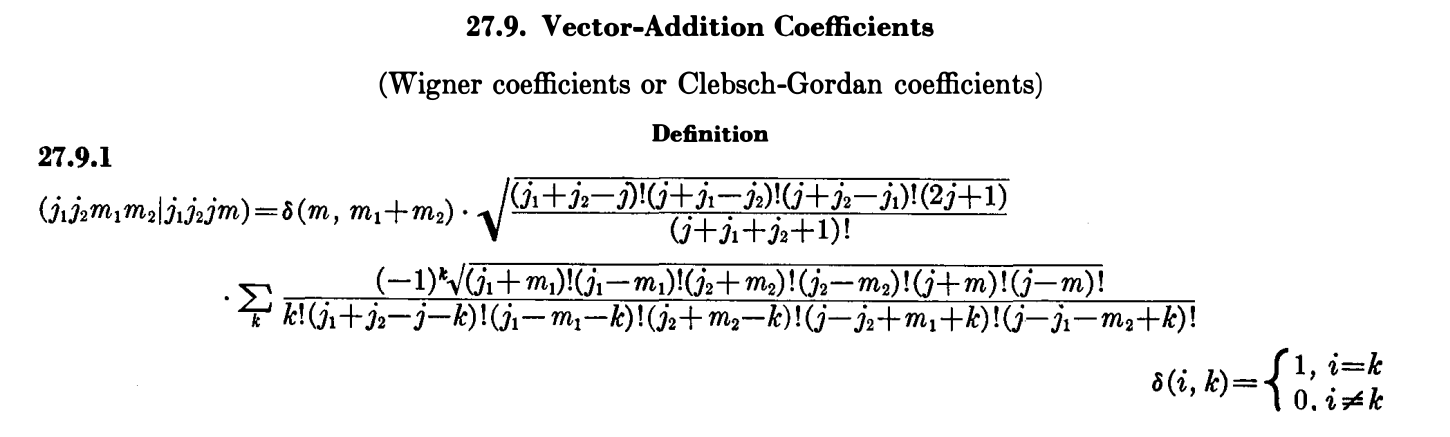

In [4]:
from scipy.special import gammaln

# Abramowitz & Stegun 27.9.1:
# gammaln(x) = ln Γ(x) and Γ(n+1) = n!, so every factorial n! in the A&S formula
# appears below as gammaln(n + 1). E.g. (j1+j2-j)! -> gammaln(j1+j2-j+1), and
# 1/(j1+j2+j+1)! -> -gammaln(j1+j2+j+2). The expression is A&S 27.9.1 verbatim,
# just written in log space (the overall 0.5* implements the square roots).

def clebsch_gordan(j1, m1, j2, m2, j, m):
    """<j1 m1 j2 m2 | j m> — A&S 27.9.1 (Condon–Shortley phase).
    Works for integer or half-integer arguments. gammaln keeps it stable to large j."""
    if abs(m1 + m2 - m) > 1e-9:                                  # δ(m, m1+m2)
        return 0.0
    if not (abs(j1 - j2) <= j <= j1 + j2):                       # triangle rule
        return 0.0
    if abs(m1) > j1 or abs(m2) > j2 or abs(m) > j:
        return 0.0

    # line 1 (sqrt prefactor) · line 2 (sqrt of the m-factorials), all in log space
    logpre = 0.5 * (
        gammaln(j1 + j2 - j + 1) + gammaln(j + j1 - j2 + 1)
        + gammaln(j + j2 - j1 + 1) + np.log(2 * j + 1) - gammaln(j1 + j2 + j + 2)
        + gammaln(j1 + m1 + 1) + gammaln(j1 - m1 + 1)
        + gammaln(j2 + m2 + 1) + gammaln(j2 - m2 + 1)
        + gammaln(j + m + 1)  + gammaln(j - m + 1)
    )

    # sum over k: every factorial argument must stay >= 0
    kmin = int(round(max(0, j2 - j - m1, j1 - j + m2)))
    kmax = int(round(min(j1 + j2 - j, j1 - m1, j2 + m2)))
    if kmax < kmin:
        return 0.0
    ks = np.arange(kmin, kmax + 1)
    logt = -(gammaln(ks + 1) + gammaln(j1 + j2 - j - ks + 1)
             + gammaln(j1 - m1 - ks + 1) + gammaln(j2 + m2 - ks + 1)
             + gammaln(j - j2 + m1 + ks + 1) + gammaln(j - j1 - m2 + ks + 1))
    signs = np.where(ks % 2 == 0, 1.0, -1.0)
    lmax = logt.max()                            # factor out largest term (cancellation-safe)
    return float(np.exp(logpre + lmax) * np.sum(signs * np.exp(logt - lmax)))

def wigner3j(j1, j2, j3, m1, m2, m3):
    """(j1 j2 j3; m1 m2 m3) = (-1)^(j1-j2-m3)/√(2j3+1) · <j1 m1 j2 m2 | j3 -m3>."""
    if abs(m1 + m2 + m3) > 1e-9:                  # 3j requires m1+m2+m3 = 0
        return 0.0
    cg = clebsch_gordan(j1, m1, j2, m2, j3, -m3)
    if cg == 0.0:
        return 0.0
    return (-1.0) ** int(round(j1 - j2 - m3)) / np.sqrt(2 * j3 + 1) * cg


# $A^{2 0}_{\ell \ell'}$

$A^{2,0}_{ℓℓ'} = \frac{8\pi}{3√5} \sqrt{(2ℓ+1)(2ℓ'+1)} (-i)^{\ell'} i^{\ell} \begin{pmatrix} \ell & 2 & \ell' \\ 0 & 0 & 0 \end{pmatrix} [ (I_ℓ+I_ℓ') + (6/7) J_{ℓℓ'} ]$

$I_ℓ   = ∫\frac{dk}{k} P_{\mathcal{R}}(k) T_{ℓ,0}(T_{ℓ,π/2}−T_{ℓ,0})$

$J_{ℓℓ'} = ∫\frac{dk}{k} P_{\mathcal{R}}(k) (T_{ℓ,π/2}−T_{ℓ,0})(T_{ℓ',π/2}−T_{ℓ',0})$
    
for $ℓ'∈{ℓ, ℓ±2}$

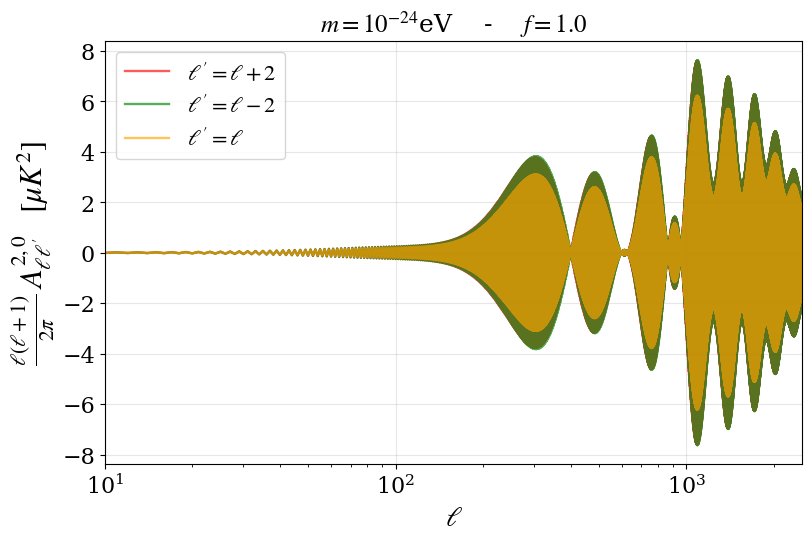

  $\ell'=\ell$ Σ|A|² = 2.8499e-05
  $\ell'=\ell+2$ Σ|A|² = 3.4389e-05
  $\ell'=\ell-2$ Σ|A|² = 3.4389e-05
  TOTAL κ₂          = 9.7278e-05


In [5]:
w3 = lambda j1, j2, j3: wigner3j(j1, j2, j3, 0, 0, 0)

tr0 = cosmo_angles[0].get_cmb_transfer()             # γ = 0
tr1 = cosmo_angles[1].get_cmb_transfer(k=tr0['k'])   # γ = π/2
k, l_nat = tr0['k'], tr0['l'].astype(int)
T0n, T1n = tr0['T'], tr1['T']
dT_nat = T1n - T0n                                   # ΔT_ℓ(k), native ℓ grid
P_R = T_cmb**2 * As * (k / 0.05)**(ns - 1.0)

PRE = 8.0*np.pi/(3.0*np.sqrt(5.0))                    # 8π/(3√5)
C_J = 6.0/7.0                                         # weight of J_ℓℓ' inside the bracket

# phase (-i)^ℓ' i^ℓ = i^(ℓ-ℓ'):  +1 for ℓ'=ℓ,  -1 for ℓ'=ℓ±2
PH_D, PH_P, PH_M = 1.0, -1.0, -1.0

L_MAX  = 2500
l_full = np.arange(2, L_MAX + 3)                     # +2 so ℓ'=ℓ+2 exists
idx = {l: i for i, l in enumerate(l_full)}
ls  = np.arange(2, L_MAX + 1)
iL  = ls - 2                                          # row of ℓ in l_full

# --- cross kernel I_ℓ (per-ℓ: integrate on native ℓ, then spline in ℓ) ---
G = T0n * dT_nat
I_nat = np.array([CubicSpline(k, P_R*G[i]/k).integrate(k[0], k[-1]) for i in range(len(l_nat))])
I = CubicSpline(l_nat, I_nat)(l_full)

# --- auto kernel J_ℓℓ' = ∫dk/k P_R ΔT_ℓ ΔT_ℓ' (coupled: ΔT interp in ℓ, then Σ_k) ---
dT = CubicSpline(l_nat, dT_nat, axis=0)(l_full)      # (n_ℓ, n_k)
w = np.empty_like(k) # Builds trapezoidal quadrature weights for the non-uniform k-grid
w[1:-1] = 0.5*(k[2:] - k[:-2])
w[0] = 0.5*(k[1]-k[0])
w[-1] = 0.5*(k[-1]-k[-2])
# J_ℓℓ' = Σ_k Sw_ℓ Sw_ℓ'
Sw = dT * np.sqrt(P_R * w / k)[None, :]                  
J_diag = np.sum(Sw[iL] * Sw[iL],    axis=1)     # J_{ℓ,ℓ}
J_plus = np.sum(Sw[iL] * Sw[iL+2],  axis=1)     # J_{ℓ,ℓ+2}
J_minus = np.full(len(ls), np.nan)
m = ls >= 4                                                 # ℓ-2 ≥ 2
J_minus[m] = np.sum(Sw[iL[m]] * Sw[iL[m]-2], axis=1)

# --- geometry √((2ℓ+1)(2ℓ'+1)) (ℓ 2 ℓ';000) per band ---
geo_d = np.array([np.sqrt((2*l+1)*(2*l+1)) * w3(l, l,   2) for l in ls])   # ℓ'=ℓ
geo_p = np.array([np.sqrt((2*l+1)*(2*l+5)) * w3(l, l+2, 2) for l in ls])   # ℓ'=ℓ+2
geo_m = np.array([np.sqrt((2*l+1)*(2*l-3)) * w3(l, l-2, 2) for l in ls])   # ℓ'=ℓ-2

# --- I_ℓ, I_ℓ' aligned to the bands ---
I_l   = I[iL]
I_lp2 = I[iL+2]
I_lm2 = np.full(len(ls), np.nan)
I_lm2[m] = I[iL[m]-2]

# --- assemble A per band:  phase · PRE · geo · [ (I_ℓ+I_ℓ') + (6/7) J_ℓℓ' ] ---
A = {
    r"$\ell'=\ell$"   : PH_D * PRE * geo_d * ((2*I_l)       + C_J*J_diag),   # I_ℓ+I_ℓ'=2I_ℓ
    r"$\ell'=\ell+2$" : PH_P * PRE * geo_p * ((I_l + I_lp2) + C_J*J_plus),
    r"$\ell'=\ell-2$" : PH_M * PRE * geo_m * ((I_l + I_lm2) + C_J*J_minus),
}

# --- plot ℓ'=ℓ±2 first, ℓ'=ℓ last (on top) ---
plot_bands = [r"$\ell'=\ell+2$", r"$\ell'=\ell-2$", r"$\ell'=\ell$"]
colors     = {r"$\ell'=\ell+2$": 'r', r"$\ell'=\ell-2$": 'g', r"$\ell'=\ell$": 'orange'}
fig, ax = plt.subplots(figsize=(9, 5.5))
for lbl in plot_bands:
    ax.plot(ls, (ls*(ls+1)/(2.*np.pi))*A[lbl], color=colors[lbl], lw=1.7, label=lbl, alpha=0.65)
ax.set(xscale='log')
ax.set_xlim(10, 2500)
ax.set_xlabel(r'$\ell$', fontsize=20)
ax.set_ylabel(r"$\frac{\ell(\ell+1)}{2\pi}\,A^{2,0}_{\ell\ell'} \quad [\mu K^2]$", fontsize=22)
ax.tick_params(axis='both', labelsize=16)
ax.legend(fontsize=16); ax.grid(alpha=0.3)
ax.set_title(r'$m= 10^{%s}$eV    -    $f = %s$'%(str(mass)[2:], str(frac)), fontsize=18)
plt.savefig('../../Figures/A20_bands_m=%s.pdf'%str(mass)[2:], bbox_inches='tight', dpi=300)
plt.show()
tot = 0.0
for lbl, y in A.items():
    s = np.nansum(y**2); tot += s
    print(f"  {lbl:12s} Σ|A|² = {s:.4e}")
print(f"  {'TOTAL κ₂':12s}      = {tot:.4e}")


# $A^{4 0}_{\ell \ell'}$

$A^{4,0}_{ℓℓ'} = \frac{32\pi}{105} \sqrt{(2ℓ+1)(2ℓ'+1)} (-i)^{\ell'} i^{\ell} \begin{pmatrix} \ell & 4 & \ell' \\ 0 & 0 & 0 \end{pmatrix}
 J_{ℓℓ'}$

$J_{ℓℓ'} = ∫\frac{dk}{k} P_{\mathcal{R}}(k) (T_{ℓ,π/2}−T_{ℓ,0})(T_{ℓ',π/2}−T_{ℓ',0})$

for   $ℓ'∈{ℓ, ℓ±2, ℓ±4}$

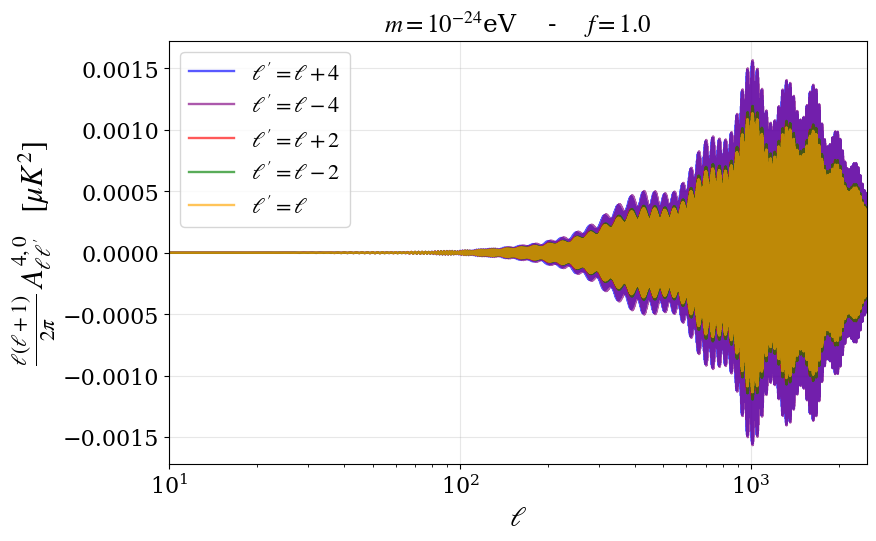

In [6]:
w3 = lambda j1, j2, j3: wigner3j(j1, j2, j3, 0, 0, 0)

tr0 = cosmo_angles[0].get_cmb_transfer()             # γ = 0
tr1 = cosmo_angles[1].get_cmb_transfer(k=tr0['k'])   # γ = π/2
k, l_nat = tr0['k'], tr0['l'].astype(int)
T0n, T1n = tr0['T'], tr1['T']
dT_nat = T1n - T0n                                   # ΔT_ℓ(k), native ℓ grid
P_R = T_cmb**2 * As * (k / 0.05)**(ns - 1.0)

PRE = 32.0*np.pi/105.0                                # 32π/105

# phase (-i)^ℓ' i^ℓ = i^(ℓ-ℓ'):  +1 for ℓ'=ℓ, ℓ±4;  -1 for ℓ'=ℓ±2
PH_D, PH_P2, PH_P4, PH_M2, PH_M4 = 1.0, -1.0, 1.0, -1.0, 1.0

L_MAX  = 2500
l_full = np.arange(2, L_MAX + 5)                     # +4 so ℓ'=ℓ+4 exists
idx = {l: i for i, l in enumerate(l_full)}
ls  = np.arange(2, L_MAX + 1)
iL  = ls - 2                                          # row of ℓ in l_full

# --- auto kernel J_ℓℓ' = ∫dk/k P_R ΔT_ℓ ΔT_ℓ' (coupled: ΔT interp in ℓ, then Σ_k) ---
dT = CubicSpline(l_nat, dT_nat, axis=0)(l_full)      # (n_ℓ, n_k)
w = np.empty_like(k)
w[1:-1] = 0.5*(k[2:] - k[:-2]); w[0] = 0.5*(k[1]-k[0]); w[-1] = 0.5*(k[-1]-k[-2])
Sw = dT * np.sqrt(P_R * w / k)[None, :]                       # J_ℓℓ' = Σ_k Sw_ℓ Sw_ℓ'
J_diag  = np.sum(Sw[iL] * Sw[iL],    axis=1)                  # J_{ℓ,ℓ}
J_plus2  = np.sum(Sw[iL] * Sw[iL+2],    axis=1)               # J_{ℓ,ℓ+2}
J_plus4  = np.sum(Sw[iL] * Sw[iL+4],    axis=1)               # J_{ℓ,ℓ+4}
J_minus2 = np.full(len(ls), np.nan)
J_minus4 = np.full(len(ls), np.nan)
m2 = ls >= 4                                                  # ℓ-2 ≥ 2
m4 = ls >= 6                                                  # ℓ-4 ≥ 2
J_minus2[m2] = np.sum(Sw[iL[m2]] * Sw[iL[m2]-2],    axis=1)   # J_{ℓ,ℓ-2}
J_minus4[m4] = np.sum(Sw[iL[m4]] * Sw[iL[m4]-4],    axis=1)   # J_{ℓ,ℓ-4}

# --- geometry √((2ℓ+1)(2ℓ'+1)) (ℓ 4 ℓ';000) per band ---
geo_d  = np.array([np.sqrt((2*l+1)*(2*l+1))     * w3(l, l,   4) for l in ls])   # ℓ'=ℓ
geo_p2 = np.array([np.sqrt((2*l+1)*(2*l+5))     * w3(l, l+2, 4) for l in ls])   # ℓ'=ℓ+2
geo_p4 = np.array([np.sqrt((2*l+1)*(2*l+9))     * w3(l, l+4, 4) for l in ls])   # ℓ'=ℓ+4
geo_m2 = np.array([np.sqrt((2*l+1)*(2*l-3))     * w3(l, l-2, 4) for l in ls])   # ℓ'=ℓ-2
geo_m4 = np.array([np.sqrt((2*l+1)*max(2*l-7,0))* w3(l, l-4, 4) for l in ls])   # ℓ'=ℓ-4 (ℓ<6 -> w3=0)

# --- assemble A per band:  phase · PRE · geo · J_ℓℓ' ---
A = {
    r"$\ell'=\ell$"   : PH_D  * PRE * geo_d  * J_diag,
    r"$\ell'=\ell+2$" : PH_P2 * PRE * geo_p2 * J_plus2,
    r"$\ell'=\ell+4$" : PH_P4 * PRE * geo_p4 * J_plus4,
    r"$\ell'=\ell-2$" : PH_M2 * PRE * geo_m2 * J_minus2,
    r"$\ell'=\ell-4$" : PH_M4 * PRE * geo_m4 * J_minus4,
}

# --- plot bands: ℓ'=ℓ±4, ℓ±2, then ℓ'=ℓ on top ---
plot_bands = [r"$\ell'=\ell+4$", r"$\ell'=\ell-4$", r"$\ell'=\ell+2$", r"$\ell'=\ell-2$", r"$\ell'=\ell$"]
colors     = {r"$\ell'=\ell+4$": 'b', r"$\ell'=\ell-4$": 'purple', r"$\ell'=\ell+2$": 'r',
              r"$\ell'=\ell-2$": 'g', r"$\ell'=\ell$": 'orange'}
fig, ax = plt.subplots(figsize=(9, 5.5))
for lbl in plot_bands:
    ax.plot(ls, (ls*(ls+1)/(2.*np.pi))*A[lbl], color=colors[lbl], lw=1.7, label=lbl, alpha=0.65)
ax.set(xscale='log')
ax.set_xlim(10, 2500)
ax.set_xlabel(r'$\ell$', fontsize=20)
ax.set_ylabel(r"$\frac{\ell(\ell+1)}{2\pi}\,A^{4,0}_{\ell\ell'} \quad [\mu K^2]$", fontsize=22)
ax.tick_params(axis='both', labelsize=16)
ax.legend(fontsize=16); ax.grid(alpha=0.3)
ax.set_title(r'$m= 10^{%s}$eV    -    $f = %s$'%(str(mass)[2:], str(frac)), fontsize=18)
plt.savefig('../../Figures/A40_bands_m=%s.pdf'%str(mass)[2:], bbox_inches='tight', dpi=300)
plt.show()